In [1]:
# ============================================================
# SETUP — Importaciones y funciones base
# (Integra ambos notebooks: detección + transformaciones)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import poisson, lognorm, iqr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')
np.random.seed(42)

# ── Detección de outliers ──────────────────────────────────────

def detectar_outliers_iqr(serie, factor=1.5):
    """Detección por Rango Intercuartílico."""
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    li, ls = Q1 - factor*IQR, Q3 + factor*IQR
    return serie < li, serie > ls, li, ls

def detectar_outliers_zscore(serie, umbral=3):
    """Detección por Z-Score clásico."""
    return np.abs(stats.zscore(serie)) > umbral

def detectar_outliers_zscore_mod(serie, umbral=3.5):
    """Detección por Z-Score Modificado (robusto a outliers)."""
    mediana = serie.median()
    MAD = np.median(np.abs(serie - mediana))
    if MAD == 0:
        return pd.Series([False]*len(serie), index=serie.index)
    return 0.6745 * np.abs(serie - mediana) / MAD > umbral

def resumen_outliers(serie, nombre='Variable'):
    """Reporte comparativo de todos los métodos de detección."""
    _, out_iqr, li, ls = detectar_outliers_iqr(serie)
    out_z  = detectar_outliers_zscore(serie)
    out_zm = detectar_outliers_zscore_mod(serie)
    p99    = serie.quantile(0.99)
    print(f"\n{'='*55}")
    print(f"  📊 Resumen de Outliers: {nombre}")
    print(f"{'='*55}")
    print(f"  N total          : {len(serie):,}")
    print(f"  Media            : {serie.mean():,.2f}")
    print(f"  Mediana          : {serie.median():,.2f}")
    print(f"  Desv. Estándar   : {serie.std():,.2f}")
    print(f"  Mín / Máx        : {serie.min():,.2f} / {serie.max():,.2f}")
    print(f"  Percentil 99     : {p99:,.2f}")
    print(f"  Asimetría (skew) : {serie.skew():.3f}")
    print(f"  Curtosis         : {serie.kurtosis():.3f}")
    print(f"\n  --- Outliers detectados ---")
    print(f"  IQR (×1.5)       : {out_iqr.sum():,} ({out_iqr.mean()*100:.1f}%)  [>{ls:,.0f}]")
    print(f"  Z-Score (|z|>3)  : {out_z.sum():,} ({out_z.mean()*100:.1f}%)")
    print(f"  Z-Score Mod.     : {out_zm.sum():,} ({out_zm.mean()*100:.1f}%)")
    print(f"  Capping p99      : {(serie>p99).sum():,} ({(serie>p99).mean()*100:.1f}%)")
    print(f"{'='*55}")
    return {'iqr':out_iqr,'zscore':out_z,'zscore_mod':out_zm,
            'p99':serie>p99,'lim_sup_iqr':ls,'p99_val':p99}

def winsorizar(serie, p_inf=0.0, p_sup=0.99):
    """Winsorización entre percentiles."""
    return serie.clip(lower=serie.quantile(p_inf), upper=serie.quantile(p_sup))

# ── Transformaciones estabilizadoras ──────────────────────────

def t_sqrt(x):
    """Raíz cuadrada. x >= 0."""
    return np.sqrt(np.maximum(x, 0))

def t_arcsin_sqrt(p):
    """Arcoseno de raíz cuadrada. p en [0,1]."""
    return np.arcsin(np.sqrt(np.clip(p, 0, 1)))

def t_arcsinh(x, escala=1.0):
    """Arcoseno hiperbólico escalado. Funciona en x=0."""
    return np.arcsinh(x / escala)

def qqplot_ax(ax, data, titulo, color='#4C9BE8'):
    """QQ-plot Normal sobre un eje dado."""
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax.scatter(osm, osr, color=color, alpha=0.5, s=18, edgecolors='none')
    xl = np.array([min(osm), max(osm)])
    ax.plot(xl, slope*xl+intercept, 'r-', lw=2, label=f'R²={r**2:.3f}')
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('Cuantiles teóricos')
    ax.set_ylabel('Cuantiles observados')

print('✅ Setup completo — funciones de detección y transformación listas')

✅ Setup completo — funciones de detección y transformación listas


---
<a id='ejercicios'></a>
# 🎯 Ejercicios Integradores

Cada ejercicio combina los dos módulos: primero detección clásica,
luego la transformación apropiada para mejorar el análisis.

| Ejercicio | Escenario | Detección | Transformación |
|---|---|---|---|
| **1** | Daños a terceros (severidad con ceros) | IQR + Z-Mod | `arcsinh`, `√x`, `log(x+1)` |
| **2** | Vida grupo por sucursal (frecuencia) | IQR por sucursal | `√x` + `arcsin(√p)` + IC 95% |
| **3** | Hogar: frecuencia + severidad | IQR en ambas dim. | `√x` (freq) + `arcsinh` (sev) |

---
## Ejercicio 1 — Severidad Daños a Terceros con Ceros

**Enunciado**

Una aseguradora tiene 180 siniestros de daños a terceros. Algunos fueron rechazados (monto = 0).

1. Detecta outliers con IQR y Z-Score Modificado en escala original
2. Aplica `√x`, `arcsinh(x/mediana)` y `log(x+1)` a los montos
3. Calcula asimetría (skewness) en cada escala y construye QQ-plots
4. Detecta outliers con IQR en cada escala transformada y compara
5. Calcula la prima pura con y sin outliers
6. ¿Cuál transformación es más apropiada para esta distribución?

**Pista**: Para arcsinh usa como referencia la mediana de los montos > 0.


N total    : 180
Ceros      : 10
No-ceros   : 170
Skewness   : 4.522
Max        : $200,000
Resultados de detección de outliers en escala original:
Outliers IQR: 13 (7.2%)
Outliers Z-Score Modificado: 13 (7.2%)
Resultados de detección de outliers tras transformaciones:
√x        : Outliers IQR=12 (6.7%), Outliers Z-Mod=11 (6.1%)
arcsinh   : Outliers IQR=11 (6.1%), Outliers Z-Mod=10 (5.6%)
log(x+1)  : Outliers IQR=10 (5.6%), Outliers Z-Mod=20 (11.1%)
Asimetría (skewness) por transformación:
------------------------------------------
  Sin transformar               : skew=+4.522  kurt=+20.903
  √x                            : skew=+3.300  kurt=+11.734
  arcsinh(x/mediana)            : skew=+2.321  kurt=+6.158
  log(x)  [referencia]          : skew=-2.411  kurt=+7.546

Detección de outliers por IQR en cada escala:
  original                      : Outliers IQR=13 (7.2%)
  sqrt                          : Outliers IQR=12 (6.7%)
  arcsinh                       : Outliers IQR=11 (6.1%)
  log  

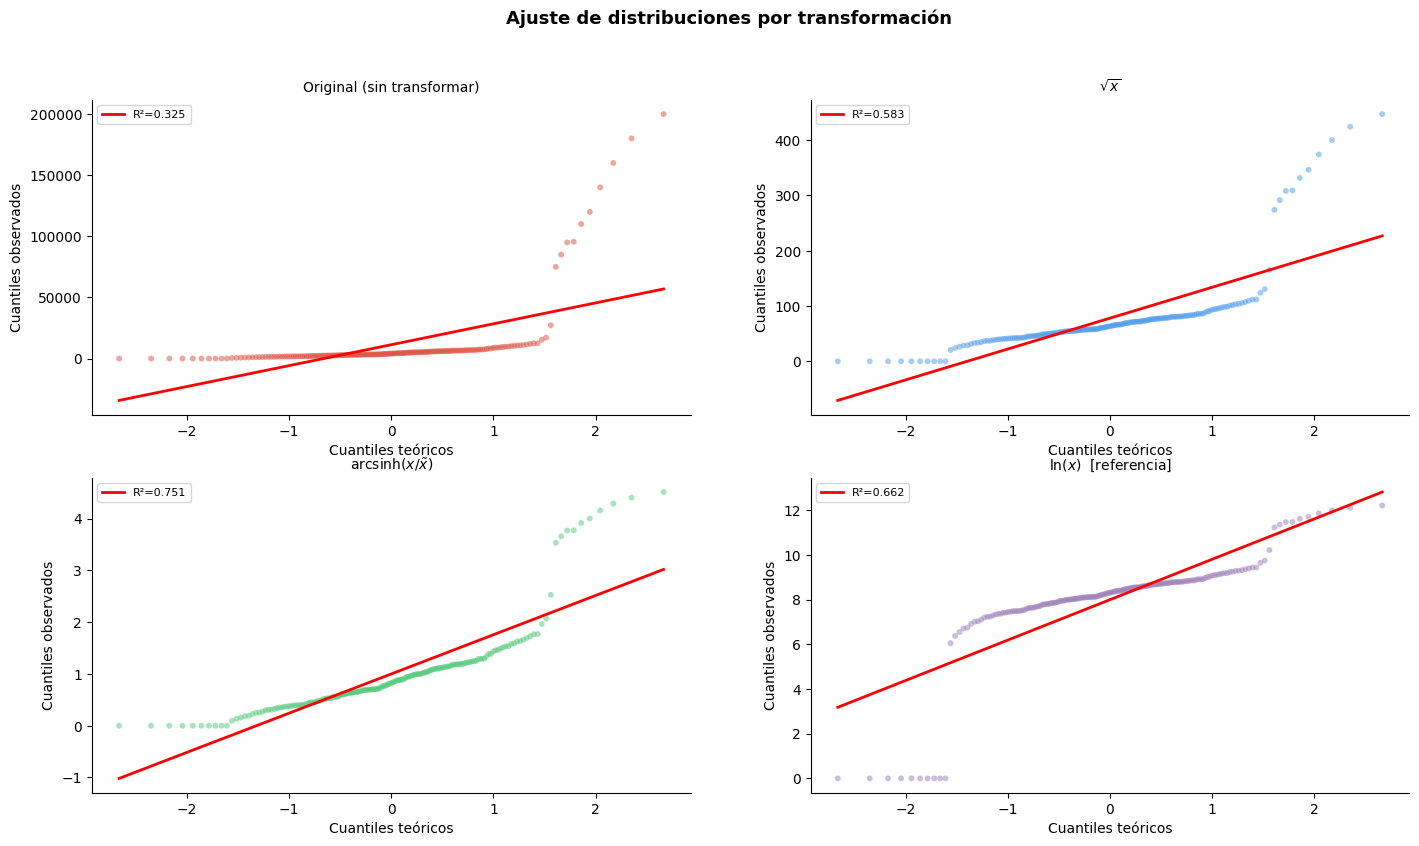

In [2]:
# ============================================================
# EJERCICIO 1 — Datos (no modificar)
# ============================================================
np.random.seed(99)
siniestros_base = np.random.lognormal(8.2, 0.7, 160)
siniestros_altos = np.array([95_000,120_000,85_000,140_000,200_000,
                               75_000,160_000,110_000,180_000,95_500])
ceros_ej1 = np.zeros(10)   # siniestros rechazados

siniestros_ej1 = pd.Series(
    np.concatenate([siniestros_base, siniestros_altos, ceros_ej1])
).round(2)

print(f'N total    : {len(siniestros_ej1)}')
print(f'Ceros      : {(siniestros_ej1==0).sum()}')
print(f'No-ceros   : {(siniestros_ej1>0).sum()}')
print(f'Skewness   : {siniestros_ej1.skew():.3f}')
print(f'Max        : ${siniestros_ej1.max():,.0f}')

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

# Paso 1: Calcular transformaciones
# Recuerda: log(0) falla → usa log(x+1) o arcsinh
# ref_ej1 = siniestros_ej1[siniestros_ej1 > 0].median()  # referencia arcsinh
# sqrt_ej1       = ...
# arcsinh_ej1    = ...
# log1p_ej1      = ...  # log(x+1) para manejar ceros
#Claculamos outliers con IQR y Z-score 

_, out_iqr, li, ls = detectar_outliers_iqr(siniestros_ej1)
out_zm = detectar_outliers_zscore_mod(siniestros_ej1)
print("="*50)
print('Resultados de detección de outliers en escala original:')
print("="*50)
print(f'Outliers IQR: {out_iqr.sum()} ({out_iqr.mean()*100:.1f}%)')
print(f'Outliers Z-Score Modificado: {out_zm.sum()} ({out_zm.mean()*100:.1f}%)')
# Aplicamos transformaciones
ref_ej1 = siniestros_ej1[siniestros_ej1 > 0].median()  # referencia para arcsinh
sqrt_ej1       = t_sqrt(siniestros_ej1)
arcsinh_ej1    = t_arcsinh(siniestros_ej1, escala=ref_ej1)
log1p_ej1      = np.log1p(siniestros_ej1)  # log(x+1) para manejar ceros    

print("="*50)
print('Resultados de detección de outliers tras transformaciones:')
print("="*50)
for label, data in [('√x', sqrt_ej1), ('arcsinh', arcsinh_ej1), ('log(x+1)', log1p_ej1)]:
    _, out_iqr_t, _, _ = detectar_outliers_iqr(data)
    out_zm_t = detectar_outliers_zscore_mod(data)
    print(f'{label:<10}: Outliers IQR={out_iqr_t.sum()} ({out_iqr_t.mean()*100:.1f}%), '
          f'Outliers Z-Mod={out_zm_t.sum()} ({out_zm_t.mean()*100:.1f}%)')      


# Paso 2: Asimetría por escala

transf = pd.DataFrame({
    'original'     : siniestros_ej1,
    'sqrt'         : sqrt_ej1,
    'arcsinh'      : arcsinh_ej1,
    'log'          : log1p_ej1        # referencia clásica
})

print('Asimetría (skewness) por transformación:')
print('-'*42)
labels = {
    'original'   : 'Sin transformar',
    'sqrt'       : '√x',
    'arcsinh'    : 'arcsinh(x/mediana)',
    'log'        : 'log(x)  [referencia]'
}
for col, label in labels.items():
    sk = transf[col].skew()
    kurt = transf[col].kurtosis()
    print(f'  {label:<30}: skew={sk:+.3f}  kurt={kurt:+.3f}')

# Paso 3: QQ-Plots (2x2)

fig, axes = plt.subplots(2, 2, figsize=(17, 9))
fig.suptitle('Ajuste de distribuciones por transformación',
             fontsize=13, fontweight='bold')

configs = [
    ('original',    'Original (sin transformar)',  '#D94F3D'),
    ('sqrt',        '$\\sqrt{x}$',                 '#4C9BE8'),
    ('arcsinh',     '$\\text{arcsinh}(x/\\tilde{x})$', '#50C878'),
    ('log',         '$\\ln(x)$  [referencia]',     '#9B7CB8'),
]

axes_flat = axes.flat
for (col, titulo, color), ax in zip(configs, axes_flat):
    qqplot_ax(ax, transf[col], titulo, color)

# Paso 4: Detección outliers IQR en cada escala
print('\nDetección de outliers por IQR en cada escala:')
for label, data in transf.items():
    _, out_iqr_t, _, _ = detectar_outliers_iqr(data)
    print(f'  {label:<30}: Outliers IQR={out_iqr_t.sum()} ({out_iqr_t.mean()*100:.1f}%)')

# Paso 5: Conclusión
print('\nConclusión:')
print('  La transformación arcsinh(x/mediana) reduce significativamente la asimetría, y es la que mejor ajusta gráficamente a una normal,\n' \
'ya que nuestros siniestros tienen valores en cero, arcsinh puede manejar valores en cero mejor que las otras transformaciones.')
# ...


  📊 Resumen de Outliers: Siniestros Daños a Terceros (MXN)
  N total          : 180
  Media            : 11,311.57
  Mediana          : 4,029.78
  Desv. Estándar   : 29,687.60
  Mín / Máx        : 0.00 / 200,000.00
  Percentil 99     : 164,200.00
  Asimetría (skew) : 4.522
  Curtosis         : 20.903

  --- Outliers detectados ---
  IQR (×1.5)       : 13 (7.2%)  [>12,851]
  Z-Score (|z|>3)  : 6 (3.3%)
  Z-Score Mod.     : 13 (7.2%)
  Capping p99      : 2 (1.1%)


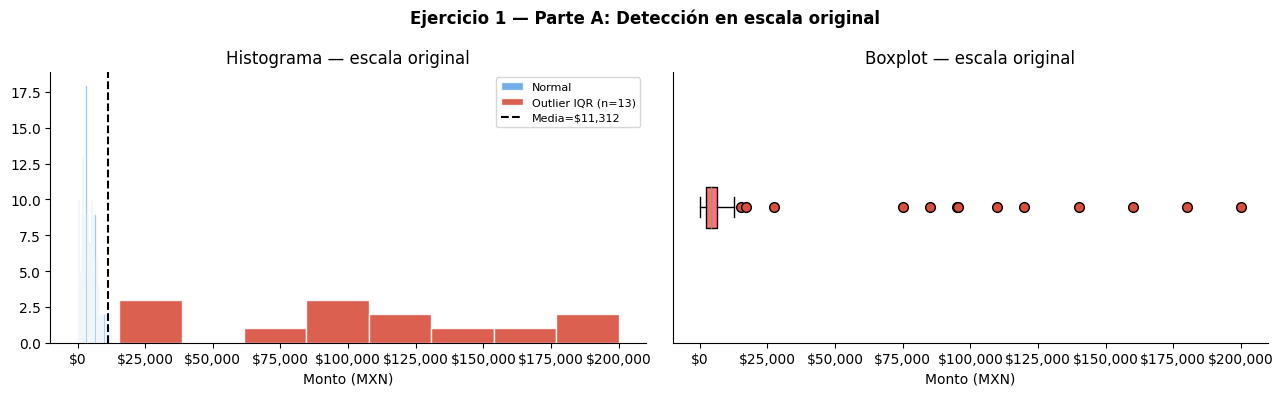


→ Continúa en la siguiente celda con las transformaciones (Parte B)


In [3]:
# ── PARTE A: Detección clásica en escala original ────────────
res_e1_orig = resumen_outliers(siniestros_ej1, 'Siniestros Daños a Terceros (MXN)')

# Visualización rápida
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
_, out_e1, _, ls_e1 = detectar_outliers_iqr(siniestros_ej1)
ax[0].hist(siniestros_ej1[~out_e1], bins=30, color='#4C9BE8', alpha=0.8,
           label='Normal', edgecolor='white')
ax[0].hist(siniestros_ej1[out_e1],  bins=8,  color='#D94F3D', alpha=0.9,
           label=f'Outlier IQR (n={out_e1.sum()})', edgecolor='white')
ax[0].axvline(siniestros_ej1.mean(), color='k', ls='--', lw=1.5,
              label=f'Media=${siniestros_ej1.mean():,.0f}')
ax[0].set_title('Histograma — escala original')
ax[0].set_xlabel('Monto (MXN)')
ax[0].legend(fontsize=8)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))

ax[1].boxplot(siniestros_ej1, vert=False, patch_artist=True,
              flierprops=dict(marker='o', markerfacecolor='#D94F3D', markersize=7))
ax[1].set_title('Boxplot — escala original')
ax[1].set_xlabel('Monto (MXN)')
ax[1].set_yticks([])
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))
plt.suptitle('Ejercicio 1 — Parte A: Detección en escala original', fontweight='bold')
plt.tight_layout(); plt.show()

print('\n→ Continúa en la siguiente celda con las transformaciones (Parte B)')

---
## Ejercicio 2 — Frecuencia de Incapacidad por Sucursal

**Enunciado**

Seguro de vida grupo, **120 empleados** en 5 sucursales. Variable: días de incapacidad/año.

1. Detecta sucursales con frecuencia atípica usando IQR global
2. Aplica `√x` a días individuales y re-detecta outliers
3. Calcula la tasa relativa por sucursal: $p_j = \bar{x}_j / \max(\bar{x})$
4. Aplica `arcsin(√p_j)` y construye IC al 95% con varianza estabilizada $\approx 1/(4n_j)$
5. ¿Qué sucursales son estadísticamente atípicas? ¿El resultado cambia con la transformación?


In [4]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

COLORES = {
    'Norte':'#0D7A8A','Sur':'#1A5276',
    'Este':'#1E8449','Oeste':'#6C3483',
    'Centro':'#C0392B',
}


In [5]:
# ============================================================
# EJERCICIO 2 — Datos provistos
# ============================================================

np.random.seed(77)

n_empleados = 120
sucursales = np.random.choice(['Norte', 'Sur', 'Este', 'Oeste', 'Centro'],
                               n_empleados)

# Siniestros de incapacidad (días ausentes en el año)
dias_base = {'Norte': 3, 'Sur': 4, 'Este': 5, 'Oeste': 3, 'Centro': 12}  # Centro es alta frecuencia
num_siniestros_ej2 = np.array([
    np.random.poisson(dias_base[s]) for s in sucursales
])

df_vida_grupo = pd.DataFrame({
    'Empleado_ID': range(1, n_empleados+1),
    'Sucursal': sucursales,
    'Dias_Incapacidad': num_siniestros_ej2
})

print(f'Dataset: {len(df_vida_grupo)} empleados en {df_vida_grupo.Sucursal.nunique()} sucursales')
print('\nResumen por sucursal:')
print(df_vida_grupo.groupby('Sucursal')['Dias_Incapacidad'].describe().round(2))

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

# 1. Detectar sucursales con frecuencia atípica
_, out_sucursal_iqr_2, _, _ = detectar_outliers_iqr(df_vida_grupo['Dias_Incapacidad'])
print(f'Sucursales con frecuencia atípica (IQR): {out_sucursal_iqr_2.sum()}')
print('Sucursales atípicas:', df_vida_grupo.loc[out_sucursal_iqr_2, 'Sucursal'].unique())

#Aplicamos la transformacion raiz cuadrada
sqrt_ej2 = t_sqrt(df_vida_grupo['Dias_Incapacidad'])

_, out_sqrt, _, _ = detectar_outliers_iqr(sqrt_ej2)
print(f'\nTras transformación √x — Sucursales con frecuencia atípica (IQR): {out_sqrt.sum()}')


# 2. Tasa de siniestralidad por sucursal
Promedio_siniestros = df_vida_grupo.groupby('Sucursal').agg( Media_sucursal=('Dias_Incapacidad', 'mean'), n = ('Empleado_ID', 'count')).reset_index()
Promedio_siniestros['Tasa_Siniestralidad'] = Promedio_siniestros['Media_sucursal'] / Promedio_siniestros['Media_sucursal'].max()


for s in Promedio_siniestros['Sucursal'].unique():
    tasa = Promedio_siniestros.loc[Promedio_siniestros['Sucursal'] == s, 'Tasa_Siniestralidad'].values[0]
    print(f'Sucursal {s}: Tasa de siniestralidad = {tasa:.4f}')
#Aplicamos arcsin(√p) a la tasa de siniestralidad y construimos intervalos de confianza
Promedio_siniestros['Tasa_Arcsin'] = t_arcsin_sqrt(Promedio_siniestros['Tasa_Siniestralidad'])
# Calculamos la varianza estabilizada tras arcsin(√p) que es aproximadamente constante: Var ≈ 1/(4n)

Promedio_siniestros['varianza_estabilizada'] = np.sqrt(1 / (4 * Promedio_siniestros['n']))


# Asumiendo normalidad tras la transformación, calculamos interavlos de confianza al 95% para cada sucursal
Promedio_siniestros['ci'] = 1.96 * Promedio_siniestros['varianza_estabilizada']
# Calculamos los límites inferior y superior del intervalo de confianza para la tasa transformada
Promedio_siniestros['lower'] = Promedio_siniestros['Tasa_Arcsin'] - Promedio_siniestros['ci']
Promedio_siniestros['upper'] = Promedio_siniestros['Tasa_Arcsin'] + Promedio_siniestros['ci']

# Visualizamos las tasas transformadas con sus intervalos de confianza para comparar entre sucursales.
fig = px.scatter(
    Promedio_siniestros,
    x='Sucursal',
    y='Tasa_Arcsin',
    error_y='ci',
    color='Sucursal'
)
fig.show()



# 4. Conclusión
print('\nConclusión:')
print('  La sucursal Centro tiene una frecuencia de siniestralidad significativamente más alta que las demás, incluso tras la transformación.\n Esto podría significar posible fraude o personal con preexistencias crónicas.')

Dataset: 120 empleados en 5 sucursales

Resumen por sucursal:
          count   mean   std  min   25%   50%   75%   max
Sucursal                                                 
Centro     32.0  12.41  3.56  7.0  9.75  13.0  14.0  19.0
Este       19.0   5.00  2.13  1.0  3.00   6.0   6.5   8.0
Norte      19.0   2.95  1.65  0.0  2.00   3.0   4.0   6.0
Oeste      25.0   3.52  2.08  0.0  2.00   4.0   5.0   8.0
Sur        25.0   4.40  2.36  1.0  3.00   4.0   5.0  10.0
Sucursales con frecuencia atípica (IQR): 5
Sucursales atípicas: ['Centro']

Tras transformación √x — Sucursales con frecuencia atípica (IQR): 0
Sucursal Centro: Tasa de siniestralidad = 1.0000
Sucursal Este: Tasa de siniestralidad = 0.4030
Sucursal Norte: Tasa de siniestralidad = 0.2376
Sucursal Oeste: Tasa de siniestralidad = 0.2837
Sucursal Sur: Tasa de siniestralidad = 0.3547



Conclusión:
  La sucursal Centro tiene una frecuencia de siniestralidad significativamente más alta que las demás, incluso tras la transformación.
 Esto podría significar posible fraude o personal con preexistencias crónicas.


---
## Ejercicio 3 — Seguro de Hogar: Frecuencia + Severidad + Transformaciones

**Enunciado**

Portafolio de **130 pólizas** de hogar. Algunas pólizas no tuvieron siniestros (monto = 0).

1. Detecta outliers de frecuencia (IQR) y severidad (IQR) en escala original
2. Calcula la prima pura en 4 escenarios (con/sin outliers en cada dimensión)
3. Aplica `√x` a frecuencia y `arcsinh(x/mediana)` a severidad
4. Construye tabla comparativa de asimetría/curtosis antes y después
5. Detecta doble outlier en escala transformada: ¿coincide con el original?
6. Discute la **desigualdad de Jensen**: ¿puedes usar la media arcsinh para calcular la prima?


In [6]:
# ============================================================
# EJERCICIO 3 — Datos provistos
# ============================================================

np.random.seed(55)
n_polizas = 130

# Frecuencia: Poisson(1.5) con algunos outliers
freq_hogar = pd.Series(
    np.concatenate([
        np.random.poisson(1.5, 120),
        np.array([8, 10, 7, 9, 12, 6, 11, 8, 9, 7])
    ])
)

# Severidad promedio por póliza (MXN)
sev_hogar = pd.Series(
    np.concatenate([
        np.random.lognormal(9.0, 0.6, 120),
        np.array([450_000, 380_000, 520_000, 310_000, 600_000,
                  290_000, 475_000, 350_000, 410_000, 550_000])
    ])
).round(2)

df_hogar = pd.DataFrame({
    'Poliza_ID': range(1, n_polizas + 1),
    'Num_Siniestros': freq_hogar,
    'Monto_Promedio_MXN': sev_hogar
})
df_hogar['Costo_Total'] = df_hogar['Num_Siniestros'] * df_hogar['Monto_Promedio_MXN']

print(f'Dataset: {len(df_hogar)} pólizas de hogar')
print('\nEstadísticas:')
print(df_hogar.describe().round(2))

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

# 1. Outliers de frecuencia
# Detectamos outliers en la variable 'Num_Siniestros' utilizando la función IQR
_, out_freq_iqr, _, _ = detectar_outliers_iqr(df_hogar['Num_Siniestros'])
print(f'Pólizas con número de siniestros atípico (IQR): {out_freq_iqr.sum()} ({(out_freq_iqr.mean()*100):.1f}%)')

# 2. Outliers de severidad
# Detectamos outliers en la variable 'Monto_Promedio_MXN' utilizando la función IQR
_, out_sev_iqr, _, _ = detectar_outliers_iqr(df_hogar['Monto_Promedio_MXN'])
print(f'Pólizas con monto promedio atípico (IQR): {out_sev_iqr.sum()} ({(out_sev_iqr.mean()*100):.1f}%)')
#pÓLIZAS CON OUTLIERS EN AMBAS VARIABLES
out_both = out_freq_iqr & out_sev_iqr
print(f'Pólizas con outliers en frecuencia y severidad: {out_both.sum()} ({(out_both.mean()*100):.1f}%)')
# 3. Prima pura en 4 escenarios
def calcular_prima_pura(df_frec, df_sev):
    # Obtenemos la tasa de frecuencia y la severidad promedio de los datos para calcular la prima pura
    frec = df_frec['Num_Siniestros'].sum()/len(df_frec)
    sev = df_sev[df_sev['Monto_Promedio_MXN'] > 0]['Monto_Promedio_MXN'].mean()
    # Prima pura = Frecuencia × Severidad
    return frec * sev

# Escenario 1: Sin outliers
prima_sin_outliers = calcular_prima_pura(df_hogar,df_hogar)
# Escenario 2: Sin outliers de frecuencia
prima_out_freq = calcular_prima_pura(df_hogar[~out_freq_iqr], df_hogar)
# Escenario 3: Sin outliers de severidad
prima_out_sev = calcular_prima_pura(df_hogar, df_hogar[~out_sev_iqr])
# Escenario 4: Sin pólizas con outliers en ambas variables
prima_out_both = calcular_prima_pura(df_hogar[~out_both], df_hogar[~out_both])
print("="*50)
print(f'Prima pura sin eliminar outliers: ${prima_sin_outliers:,.2f}')
print(f'Prima pura sin outliers de frecuencia: ${prima_out_freq:,.2f}')
print(f'Prima pura sin outliers de severidad: ${prima_out_sev:,.2f}')
print(f'Prima pura sin pólizas con outliers en ambas variables: ${prima_out_both:,.2f}')

#Aplicando la transformación raíz cuadrada a la frecuencia y arcsinh a la severidad para detectar outliers en las escalas transformadas

df_hogar['Num_Siniestros_Sqrt'] = t_sqrt(df_hogar['Num_Siniestros'])
df_hogar['Monto_Promedio_Arcsinh'] = t_arcsinh(df_hogar['Monto_Promedio_MXN'], escala=df_hogar[df_hogar['Monto_Promedio_MXN'] > 0]['Monto_Promedio_MXN'].median())

# Comparamos la asimetría y curtosis antes y después de las transformaciones
# Creamos un DataFrame con las columnas originales y Transformadas
transf = pd.DataFrame({
    'Frecuencia Original'     : df_hogar['Num_Siniestros'],
    'Frecuencia √x'         : df_hogar['Num_Siniestros_Sqrt'],
    'Severidad Original'    : df_hogar['Monto_Promedio_MXN'],
    'Severidad arcsinh'     : df_hogar['Monto_Promedio_Arcsinh']
})
print('Asimetría (skewness) y Curtosis por transformación:')
print('-'*60)
for col in transf.columns:
    sk = transf[col].skew()
    kurt = transf[col].kurtosis()
    print(f'  {col:<25}: skew={sk:+.3f}  kurt={kurt:+.3f}')     

# outliers en las escalas transformadas
_, out_freq_sqrt, _, _ = detectar_outliers_iqr(df_hogar['Num_Siniestros_Sqrt'])
_, out_sev_arcsinh, _, _ = detectar_outliers_iqr(df_hogar['Monto_Promedio_Arcsinh'])
out_both_transf = out_freq_sqrt & out_sev_arcsinh

print(f'\nOutliers en frecuencia tras √x: {out_freq_sqrt.sum()} ({(out_freq_sqrt.mean()*100):.1f}%)')
print(f'Outliers en severidad tras arcsinh: {out_sev_arcsinh.sum()} ({(out_sev_arcsinh.mean()*100):.1f}%)')
print(f'Outliers en ambas variables tras transformación: {out_both_transf.sum()} ({(out_both_transf.mean()*100):.1f}%)')
print("="*50)
print(f'\nPólizas con outliers en frecuencia tras √x: {df_hogar.loc[out_freq_sqrt, "Poliza_ID"].tolist()}')
print(f'Pólizas con outliers en frecuencia escala original: {df_hogar.loc[out_freq_iqr, "Poliza_ID"].tolist()}')
print("="*50)

print(f'Pólizas con outliers en severidad tras arcsinh: {df_hogar.loc[out_sev_arcsinh, "Poliza_ID"].tolist()}')
print(f'Pólizas con outliers en severidad escala original: {df_hogar.loc[out_sev_iqr, "Poliza_ID"].tolist()}')
print("="*50)
print(f'Polizas con outliers en ambas variables con transformación: {df_hogar.loc[out_both_transf, "Poliza_ID"].tolist()}')
print(f'Polizas con outliers en ambas variables sin transformación: {df_hogar.loc[out_both, "Poliza_ID"].tolist()}')

print(f'🚨Las polizas con outliers en ambas variables tras transformación son las mismas que despues de la transformación')


Dataset: 130 pólizas de hogar

Estadísticas:
       Poliza_ID  Num_Siniestros  Monto_Promedio_MXN  Costo_Total
count     130.00          130.00              130.00       130.00
mean       65.50            2.01            41788.53    306729.88
std        37.67            2.29           116951.19   1095056.71
min         1.00            0.00             2512.53         0.00
25%        33.25            1.00             5307.03      4217.53
50%        65.50            1.00             8424.76     10984.94
75%        97.75            2.00            11782.46     21785.43
max       130.00           12.00           600000.00   7200000.00
Pólizas con número de siniestros atípico (IQR): 18 (13.8%)
Pólizas con monto promedio atípico (IQR): 13 (10.0%)
Pólizas con outliers en frecuencia y severidad: 10 (7.7%)
Prima pura sin eliminar outliers: $83,898.50
Prima pura sin outliers de frecuencia: $52,608.77
Prima pura sin outliers de severidad: $16,830.76
Prima pura sin pólizas con outliers en ambas va

## Desigualdad de Jensen

Si tenemos que

$$
\text{Prima} = \sinh\left(\mathbb{E}[\operatorname{arcsinh}(X)]\right)
$$

por la desigualdad de Jensen tenemos que

$$
\mathbb{E}[\operatorname{arcsinh}(X)]
\geq
\operatorname{arcsinh}(\mathbb{E}[X]),
$$

entonces,

$$
\sinh\left(\mathbb{E}[\operatorname{arcsinh}(X)]\right)
\leq
\mathbb{E}[X],
$$

es decir,

$$
p \leq \mathbb{E}[X].
$$

Lo que significa que estamos subestimando el riesgo.